In [ ]:
########################
# CNN su FashionMNIST  #
########################

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1. Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [2]:
# 2. Dataset
batch_size = 256

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [3]:
# 3. Modello CNN minimale
model = nn.Sequential(
    # Convoluzione
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),     # 28x28 -> 14x14

    # Seconda convoluzione
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),     # 14x14 -> 7x7

    # Classificatore
    nn.Flatten(),
    nn.Linear(32 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

print(model)

Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1568, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
# 4. Loss e ottimizzatore
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# 5. Funzione accuracy
def accuracy(model, dataloader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            preds = model(X).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

# 6. Training loop
num_epochs = 10
train_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        logits = model(X)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    epoch_loss = running_loss / total
    epoch_train_acc = correct / total
    epoch_test_acc = accuracy(model, test_loader)

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_train_acc)
    test_accuracies.append(epoch_test_acc)

    print(
        f"Epoca {epoch:02d} | "
        f"Loss train: {epoch_loss:.4f} | "
        f"Acc train: {epoch_train_acc:.4f} | "
        f"Acc test: {epoch_test_acc:.4f}"
    )


Epoca 01 | Loss train: 0.8661 | Acc train: 0.6905 | Acc test: 0.7592
Epoca 02 | Loss train: 0.4629 | Acc train: 0.8271 | Acc test: 0.8309
Epoca 03 | Loss train: 0.3914 | Acc train: 0.8565 | Acc test: 0.8626
Epoca 04 | Loss train: 0.3549 | Acc train: 0.8696 | Acc test: 0.8453
Epoca 05 | Loss train: 0.3305 | Acc train: 0.8787 | Acc test: 0.8707
Epoca 06 | Loss train: 0.3105 | Acc train: 0.8854 | Acc test: 0.8728
Epoca 07 | Loss train: 0.2945 | Acc train: 0.8911 | Acc test: 0.8734
Epoca 08 | Loss train: 0.2805 | Acc train: 0.8965 | Acc test: 0.8779
Epoca 09 | Loss train: 0.2706 | Acc train: 0.9002 | Acc test: 0.8751
Epoca 10 | Loss train: 0.2600 | Acc train: 0.9049 | Acc test: 0.8870


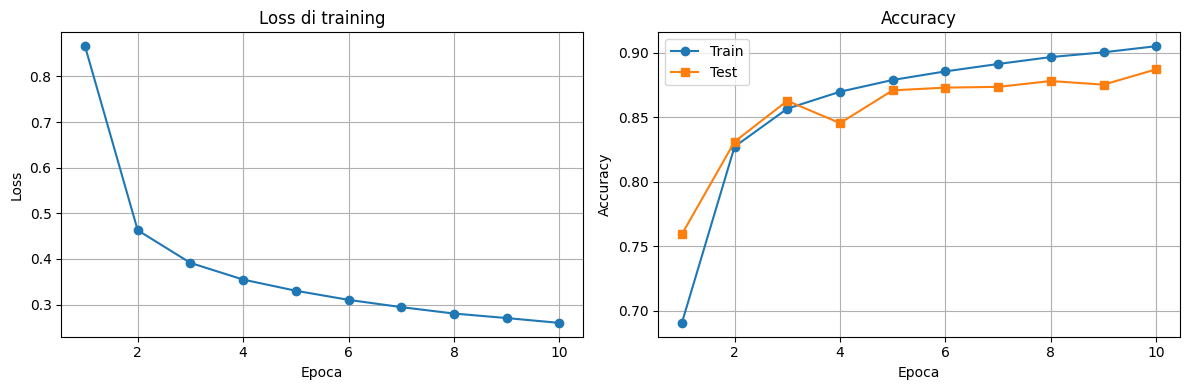

In [ ]:
# 7. Plot
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, marker="o")
plt.title("Loss di training")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, marker="o", label="Train")
plt.plot(epochs, test_accuracies, marker="s", label="Test")
plt.title("Accuracy")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()